# 📘 Reflection Seismic Data Processing Notebook
FieldCamp II - June 2025

This notebook guides you through the steps of reading, visualizing, and processing seismic shot data using Python.

---

# 1. Installation

## 1.1 Python modules

**After you run this cell. It will ask you to restart your session**. Only run this once.

In [1]:
import sys

if 'google.colab' in sys.modules:
    !pip install obspy obsplus pyproj segyio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.3/344.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.1/85.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.7 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.41
    Uninstalling SQLAlchemy-2.0.41:
      Successfully uninstalled SQLAlchemy-2.0.41
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0

## 1.2. Clone Field Camp II Library (fc2)

In [2]:
!git clone https://github.com/ecastillot/FieldCampII_2025.git /content/FieldCampII_2025

Cloning into '/content/FieldCampII_2025'...
remote: Enumerating objects: 517, done.
remote: Counting objects: 100% (278/278), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 517 (delta 142), reused 223 (delta 89), pack-reused 239 (from 1)
Receiving objects: 100% (517/517), 662.01 MiB | 23.61 MiB/s, done.
Resolving deltas: 100% (185/185), done.


In [3]:
import sys
lib = "/content/FieldCampII_2025"
sys.path.append(lib)

# 1.3. Test

In [4]:
from obspy import UTCDateTime # obspy
from fc2.seismic import read_shots_from_folder,plot_shot_data #fc2

# 2. Download data

Projects:


*   **PF** - Packery Flats (June 14th, 2025)
*   **BHR_E** - Big Hill Road, End (June 18th, 2025)
*   **BHR_M** - Big Hill Road, Middle (June 19th, 2025)


In [ ]:
# Select your project
project = "PF"


# Don't modify this code
data_dropbox = {"PF": "https://www.dropbox.com/scl/fo/tkeerdr54zz6r3psn61y1/ABIXTjSj-xDSgWm9sH-jjks?rlkey=jyw3s1cfk8mm3tcu5vuy8u8rk&e=1&dl=1",
                "BHR_E": "https://www.dropbox.com/scl/fo/yohnd85l59tk6042o4ila/AIvPutdEnOXxYF093J978y4/Passive_BHRend?rlkey=4muc9fcx831osbwlsnzek48gw&subfolder_nav_tracking=1&st=gwwmbe2w&dl=1",
                "BHR_M": "https://www.dropbox.com/scl/fo/yohnd85l59tk6042o4ila/API0Hk1PvsadRCTw4E3asOA/Passive_BHRmiddle?rlkey=4muc9fcx831osbwlsnzek48gw&subfolder_nav_tracking=1&st=6zm0a75w&dl=1"}

!wget -O "{project}.zip" "{data_dropbox[project]}"
!unzip  "{project}.zip" -d  "{project}"

--2025-06-25 19:07:02--  https://www.dropbox.com/scl/fo/tkeerdr54zz6r3psn61y1/ABIXTjSj-xDSgWm9sH-jjks?rlkey=jyw3s1cfk8mm3tcu5vuy8u8rk&e=1&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc706f29fb13323e5f897b900e29.dl.dropboxusercontent.com/zip_download_get/CPvomiSWol6vrmuUs2iU5-ndvQSOoYiX7x62EhM_ysNYZ1szZmS-KuDBNNiXhIx0aVBoIexWZGYH8qMa_0TwHwKddUjAGcozEcFwCFRJxxstPQ# [following]
--2025-06-25 19:07:03--  https://uc706f29fb13323e5f897b900e29.dl.dropboxusercontent.com/zip_download_get/CPvomiSWol6vrmuUs2iU5-ndvQSOoYiX7x62EhM_ysNYZ1szZmS-KuDBNNiXhIx0aVBoIexWZGYH8qMa_0TwHwKddUjAGcozEcFwCFRJxxstPQ
Resolving uc706f29fb13323e5f897b900e29.dl.dropboxusercontent.com (uc706f29fb13323e5f897b900e29.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:601d:15::a27d:50f
Connecting to uc706f29fb13323e5f897b900e29.

# Load data

In [13]:
# 🧰 Step 1: Import necessary libraries -DON'T MODIFY THIS
import pandas as pd        # for reading and working with tabular data
import os                  # for working with file paths
import numpy as np         # for numerical operations
import matplotlib.pyplot as plt  # for plotting
from obspy import UTCDateTime    # to work with seismic time formats

# Import helper functions from our custom `seismic` module
from fc2.seismic import (
    separate_shot_groups,       # separates shot data by group (e.g., P, S waves)
    plot_shot_data,             # plots summary data for shots
    plot_shot_geometry,         # plots geometry of sources and receivers
    read_waveforms,             # reads seismic waveform data from disk
    get_receiver_data,          # formats and cleans receiver data
    get_shots_data,             # merges and cleans shot location and time data
    process_and_export_shots    # performs waveform slicing, filtering, plotting, exporting
)

In [16]:
# 📁 Step 2: Load input data (CSV files) -DON'T MODIFY THIS

receiver_geometry_path = os.path.join("/content/FieldCampII_2025/data/seismic",project,"receiver_geometry.csv")
shots_labeled_path = os.path.join("/content/FieldCampII_2025/data/seismic",project,"shots_labeled.csv")
source_geometry_path = os.path.join("/content/FieldCampII_2025/data/seismic",project,"source_geometry.csv")

out_folder = "/content/OUTPUT"
os.makedirs(out_folder,exist_ok=True)

shots_labeled = pd.read_csv(shots_labeled_path)
source_geometry = pd.read_csv(source_geometry_path)
receiver_geometry = pd.read_csv(receiver_geometry_path)

receiver_geometry = get_receiver_data(receiver_geometry)
shots_geometry = get_shots_data(shots_labeled, source_geometry)
shots_groups = separate_shot_groups(shots_geom=shots_geometry)

print("Receiver geometry")
display(receiver_geometry.head())
print("Source geometry")
display(source_geometry.head())
print("Available Seismic")
print(list(shots_groups.keys()))



Receiver geometry


,Receiver Number,gx,gy,gelev,x-coordinate (m)
Node ID,,,,,
24311,1,0,0,0,0.0
25794,2,1,0,0,1.5
26107,3,3,0,0,3.0
26132,4,4,0,0,4.5
26226,5,6,0,0,6.0


Source geometry


,Shot Location,x-coodinate (m)
0,1,0
1,2,3
2,3,6
3,4,9
4,5,12


Available Seismic
['P', 'S_N', 'S_S']


Group: P, Number of subgroups: 16
Shots per subgroup: {'P1': 6, 'P10': 6, 'P11': 6, 'P12': 6, 'P13': 6, 'P14': 6, 'P15': 6, 'P16': 6, 'P2': 6, 'P3': 6, 'P4': 6, 'P5': 6, 'P6': 6, 'P7': 6, 'P8': 6, 'P9': 6}
Plot saved to /content/OUTPUT/shots_P_data.png


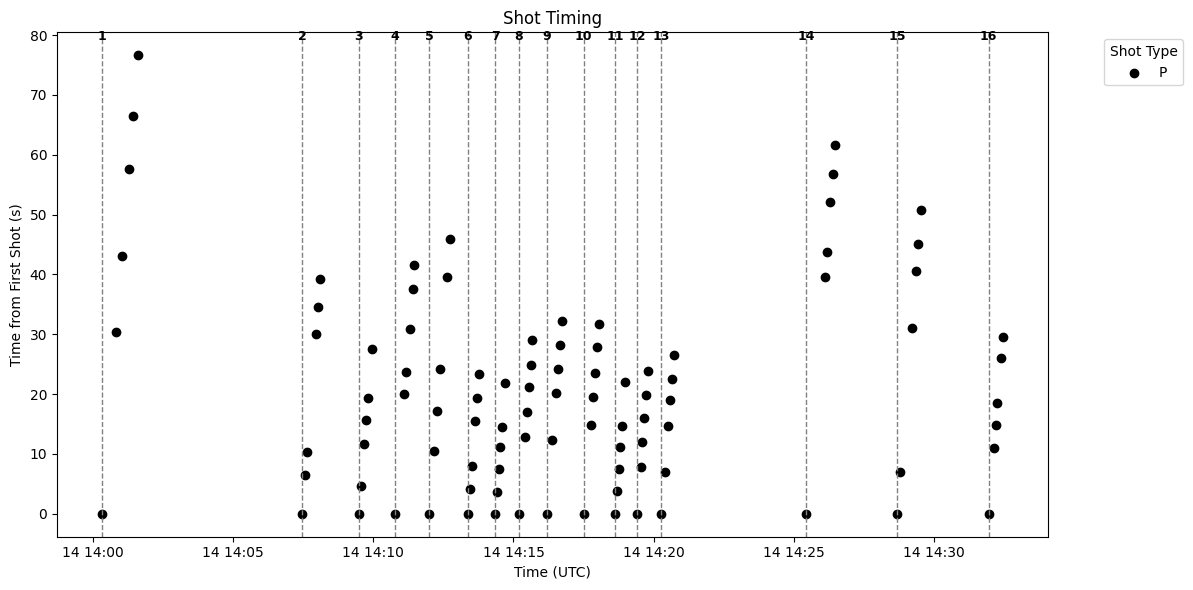

Plot saved to /content/OUTPUT/shots_P_geometry.png


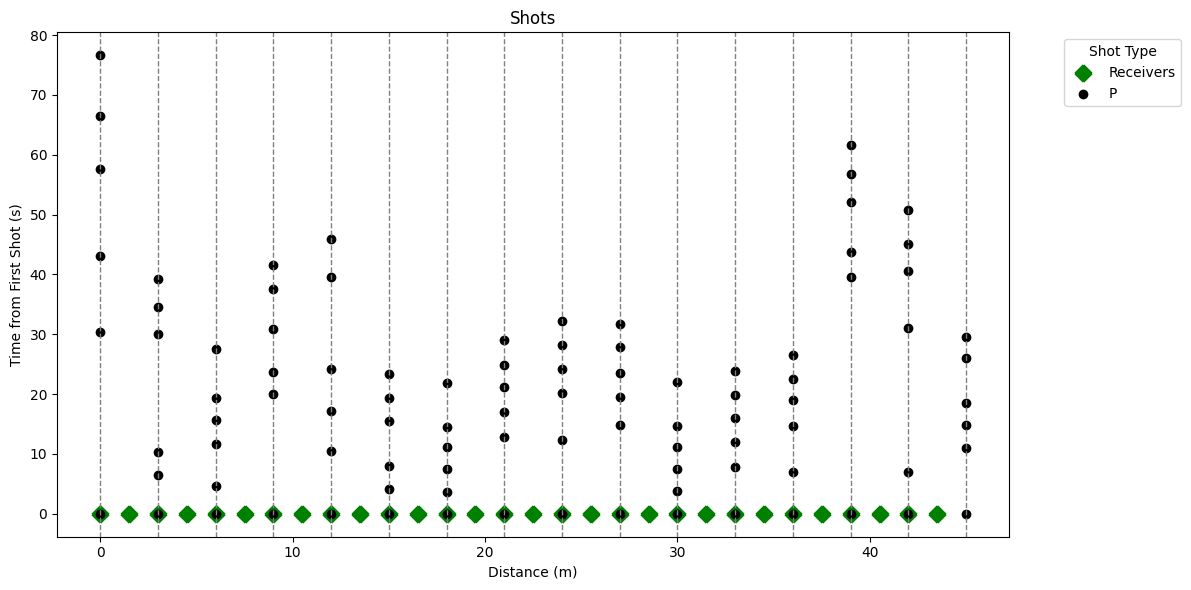

Group: S_N, Number of subgroups: 16
Shots per subgroup: {'S10_N': 5, 'S11_N': 6, 'S12_N': 6, 'S13_N': 6, 'S14_N': 6, 'S15_N': 6, 'S16_N': 6, 'S1_N': 6, 'S2_N': 6, 'S3_N': 6, 'S4_N': 6, 'S5_N': 6, 'S6_N': 6, 'S7_N': 6, 'S8_N': 6, 'S9_N': 6}
Plot saved to /content/OUTPUT/shots_S_N_data.png


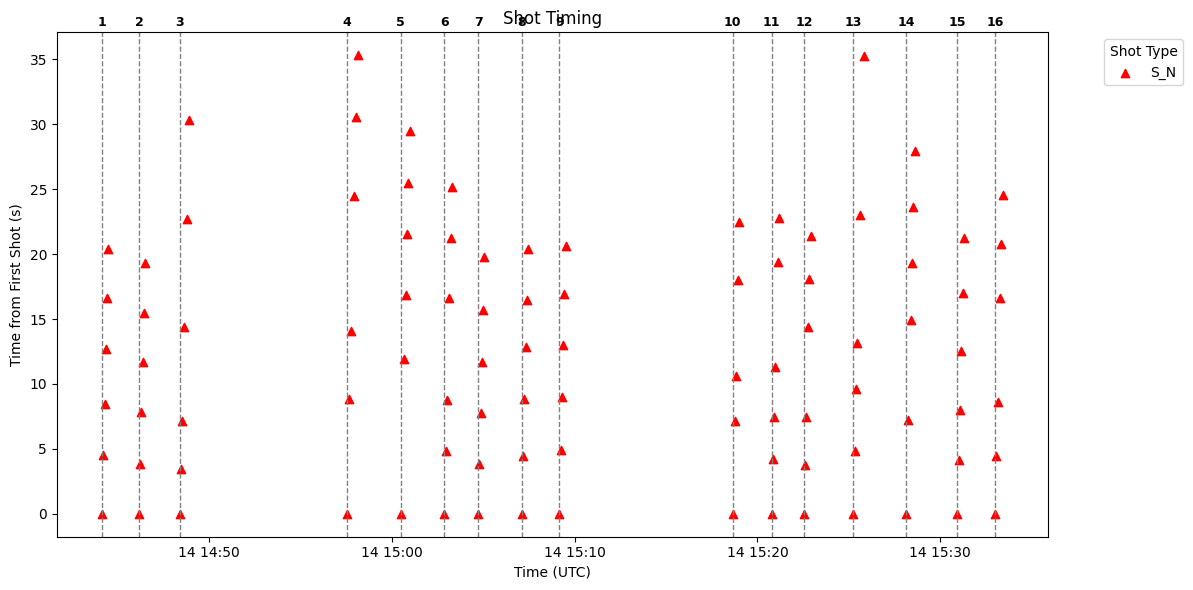

Plot saved to /content/OUTPUT/shots_S_N_geometry.png


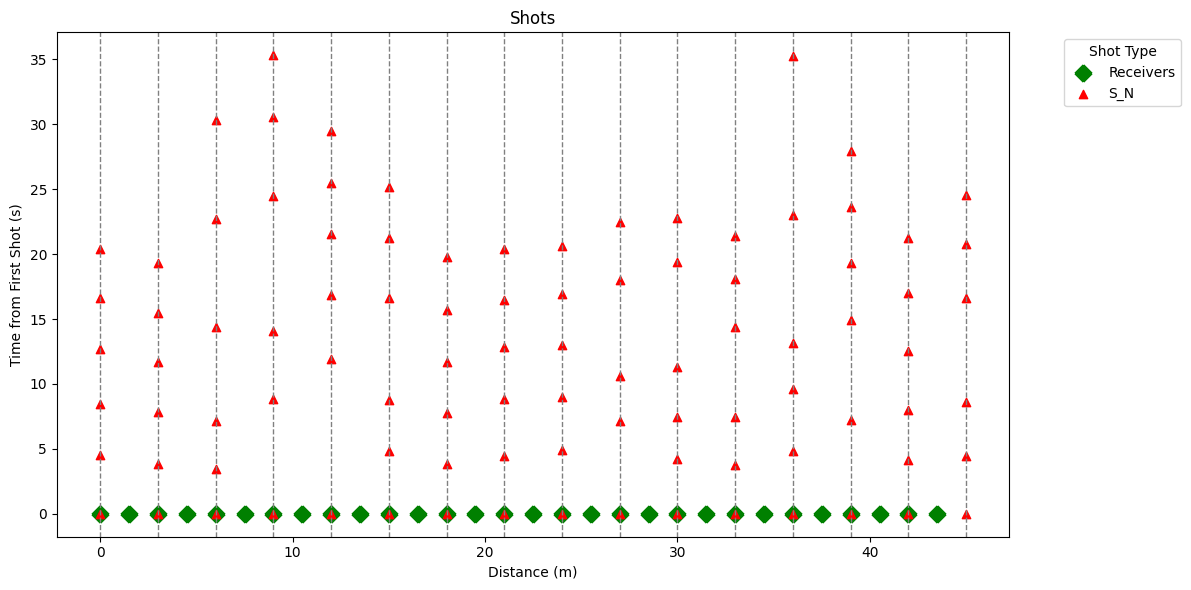

Group: S_S, Number of subgroups: 16
Shots per subgroup: {'S10_S': 6, 'S11_S': 6, 'S12_S': 6, 'S13_S': 6, 'S14_S': 6, 'S15_S': 6, 'S16_S': 6, 'S1_S': 6, 'S2_S': 6, 'S3_S': 6, 'S4_S': 6, 'S5_S': 6, 'S6_S': 6, 'S7_S': 6, 'S8_S': 6, 'S9_S': 5}
Plot saved to /content/OUTPUT/shots_S_S_data.png


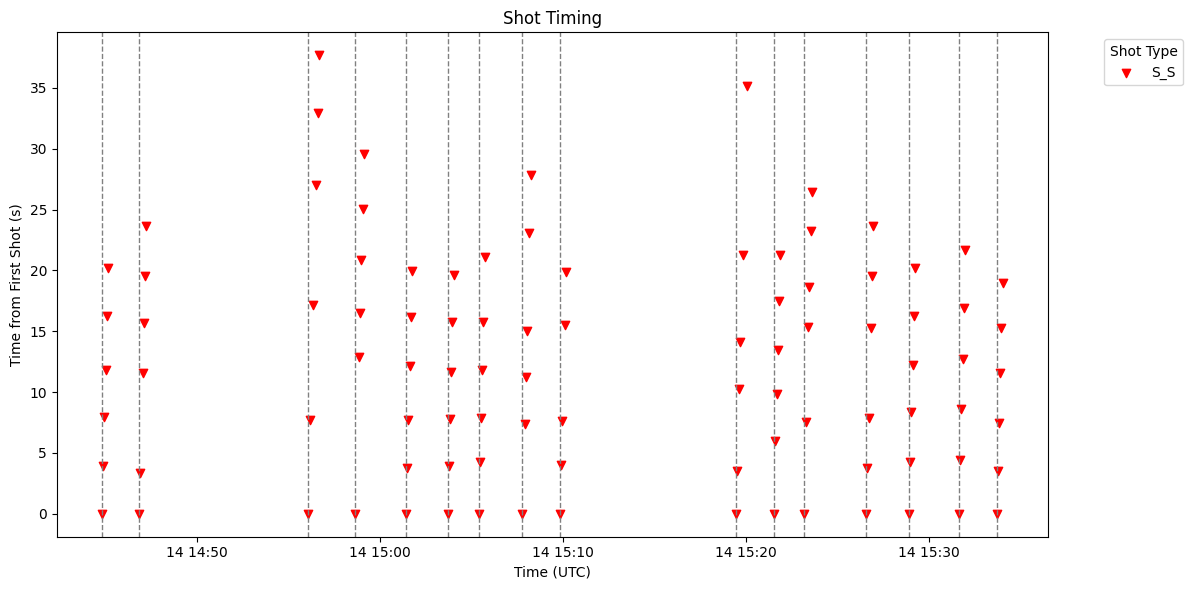

Plot saved to /content/OUTPUT/shots_S_S_geometry.png


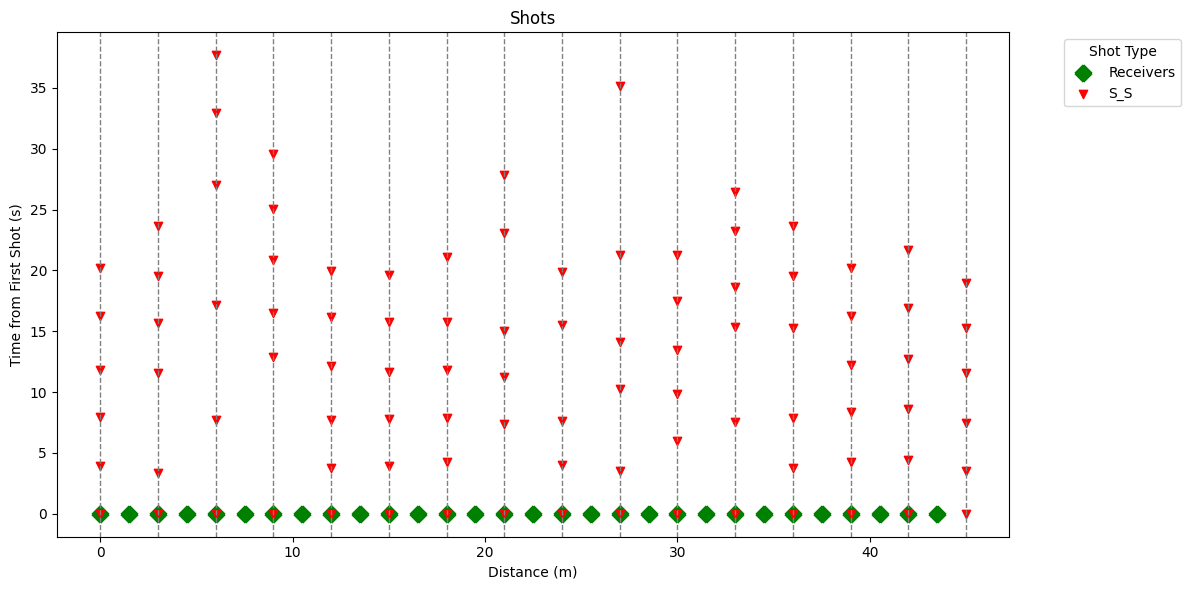

In [18]:
# 🗺️ Step 3: Visualize shot geometry and data -DON'T MODIFY THIS

for group_name, shots in shots_groups.items():
    print(f"Group: {group_name}, Number of subgroups: {len(shots.groupby('shot_group'))}")
    print(f"Shots per subgroup: {shots.groupby('shot_group').size().to_dict()}")

    plot_shot_data(
        shots,
        save_path=os.path.join(out_folder, f"shots_{group_name}_data.png")
    );

    plot_shot_geometry(
        shots,
        receiver=receiver_geometry,
        save_path=os.path.join(out_folder, f"shots_{group_name}_geometry.png")
    );

# Processing

In [19]:
# Define waveform folder and time window
shot_type = "P" #phase to process: "P", "S_N", "S_S". If you use S wave be sure to use "E" component when you read the waveforms
component = "Z"

# DON'T MODIFY THE CODE BELOW
smart_solo_folder = f"/content/{project}"
starttime = UTCDateTime(shots_groups[shot_type]["time"].min()) - 5
endtime = UTCDateTime(shots_groups[shot_type]["time"].max()) + 10

st = read_waveforms(
    folder_path=smart_solo_folder,
    component=component,
    starttime=starttime,
    endtime=endtime
)

print(f"Number of traces: {len(st)}")

Number of traces: 30


In [20]:
# ⚙️ Step 5: Define processing parameters
processing = {}

## Define padding or delay centered around the shot time
processing["left_seconds"] = 0.001
processing["right_seconds"] = 0.6
processing["delay_dict"] = {}  # {"2":0.08,"37": 0.2}  # example delay for shot number 2 and 37


# Define filtering and normalization parameters
processing["apply_filter"] = True
processing["freqmin"] = 20
processing["freqmax"] = 60
processing["normalization"] = True

# Define output options
processing["plot"] = True
processing["only_specific_shots"] = []  # if you only want to work in some specific
                                        # shots, use a list like this: [1,34,53]  # for shots 1 , 34 and 57

# DON'T MODIFY THE CODE BELOW
processing["export_segy"] = False
processing["verbose"] = True
processing["phase"] = shot_type

In [23]:
# 🧪 Step 6: Process seismic shots # DON'T MODIFY THE CODE BELOW
process_and_export_shots(
    st=st,
    shots_groups=shots_groups,
    receiver_geometry=receiver_geometry,
    out_folder=out_folder,
    phase=processing["phase"],
    left_seconds=processing["left_seconds"],
    right_seconds=processing["right_seconds"],
    delay_dict=processing["delay_dict"],
    apply_filter=processing["apply_filter"],
    freqmin=processing["freqmin"],
    freqmax=processing["freqmax"],
    normalization=processing["normalization"],
    plot=processing["plot"],
    only_specific_shots=processing["only_specific_shots"],
    export_segy=processing["export_segy"],
    verbose=processing["verbose"]
)

proc_path = os.path.join(out_folder,"processing")
print(f"Check your results here: f{proc_path}")


Processing shot 1/96: P1 - 1 | Shot time: 2025-06-14T14:00:18.885000Z
	Applying delay: 0.0 seconds
	Writing shot group P1, strike 1 with 30 traces

Processing shot 2/96: P1 - 2 | Shot time: 2025-06-14T14:00:49.285000Z
	Applying delay: 0.0 seconds
	Writing shot group P1, strike 2 with 30 traces

Processing shot 3/96: P1 - 3 | Shot time: 2025-06-14T14:01:01.982000Z
	Applying delay: 0.0 seconds
	Writing shot group P1, strike 3 with 30 traces

Processing shot 4/96: P1 - 4 | Shot time: 2025-06-14T14:01:16.579000Z
	Applying delay: 0.0 seconds
	Writing shot group P1, strike 4 with 30 traces

Processing shot 5/96: P1 - 5 | Shot time: 2025-06-14T14:01:25.298000Z
	Applying delay: 0.0 seconds
	Writing shot group P1, strike 5 with 30 traces

Processing shot 6/96: P1 - 6 | Shot time: 2025-06-14T14:01:35.507000Z
	Applying delay: 0.0 seconds
	Writing shot group P1, strike 6 with 30 traces

Processing shot 7/96: P2 - 1 | Shot time: 2025-06-14T14:07:27.445000Z
	Applying delay: 0.0 seconds
	Writing sho

In [ ]:
from IPython.display import Image, display

fname = "P11_strike_2"

# Display the image
path = os.path.join(out_folder,"procesing",f"{fname}.png")
display(Image(filename='path_to_your_image.png'))